# Notebook 6 — Pruebas finales: multimodal FC + Topologia

**Objetivo:** superar el MAE de referencia del Thesis (**5.70 anos** en test CN, config `Z + T1w + sex`) incorporando metricas topologicas de grafos.

## Estrategia
1. **Replica estricta** del pipeline Thesis: cohorte, split estratificado, hiperparametros Optuna, entrenamiento solo CN.
2. **VAE multimodal**: entrada `FC(6670) + TOPO(6)` con los mismos hiperparametros del beta-VAE Thesis.
3. **Regresor final** `tf.keras.Sequential`: `Z(64) + T1w(116) + TOPO(6) + sex(1)` = 187 features.
4. Comparacion contra baseline Thesis (`Z_fc + T1w + sex`, XGBoost) en **5-fold CV** y **test holdout**.

## Referencia Thesis (main.ipynb, test CN)
| Modelo | MAE | R2 |
|--------|-----|----|
| XGBoost Z+T1w+sex | **5.70** | 0.389 |
| SVR Z+T1w | 5.65 | 0.441 |

> Si existe `Thesis/Outputs/` (splits, VAE, embeddings), se reutilizan automaticamente.

In [4]:
import sys, os, json
sys.path.insert(0, "Thesis/Code")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor

from src.config import DEFAULT_PATHS, ExperimentConfig
from src.cohort import build_final_cohort_df
from src.splits import make_holdout_split, load_splits, save_splits
from src.vae_train import train_vae_final, load_vae_from_dir
from src.embeddings import load_embeddings
from src.metrics import regression_metrics

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="colorblind")
os.makedirs("figs", exist_ok=True)
os.makedirs("outputs", exist_ok=True)
os.makedirs("outputs/models_multimodal_vae", exist_ok=True)

SEED = 42
cfg   = ExperimentConfig(seed=SEED)
paths = DEFAULT_PATHS
tf.random.set_seed(SEED)
np.random.seed(SEED)

TOPO = [
    "local_efficiency", "global_efficiency", "clustering_coeff",
    "fp_local_efficiency", "fp_betweenness", "fp_degree",
]

# Hiperparametros Thesis (Optuna)
VAE_HP = dict(
    hidden_dims=[512], latent_dim=64, activation="elu",
    norm_kind="layer", beta_target=0.0567, warmup_ep=73,
    l2_reg=1e-4, drop_rate=0.0369, recon_kind="mae",
    lr=0.001892, clipnorm=1.0, max_epochs=150, batch_size=64,
)
XGB_HP = dict(
    n_estimators=2103, max_depth=6, learning_rate=0.0110,
    subsample=0.5021, colsample_bytree=0.9506,
    reg_alpha=0.00136, reg_lambda=7.084, min_child_weight=1.142,
    gamma=0.675, tree_method="hist", eval_metric="mae",
    random_state=SEED, verbosity=0,
)
make_xgb = lambda: Pipeline([
    ("sc", StandardScaler()),
    ("m", XGBRegressor(**XGB_HP)),
])

THESIS_TEST_MAE = 5.70
print("Setup completo.")

Setup completo.


## 1. Cohorte, split y matrices de features

In [5]:
# --- Cohorte: interseccion FC + T1w + topologia ---
graph_df = pd.read_csv("outputs/graph_metrics_table.csv")
vbm_raw  = pd.read_csv("outputs/vbm_features.csv")
t1w_cols = [c for c in vbm_raw.columns
            if c.startswith("gm_") and c not in ["gm_total", "gm_fp_mean"]]

df = (
    graph_df
    .merge(vbm_raw[["MRI_ID"] + t1w_cols], on="MRI_ID", how="left")
    .dropna(subset=["Age"] + TOPO)
    .reset_index(drop=True)
)

FC_DIR = Path("outputs/fc_matrices")
triu_i, triu_j = np.triu_indices(116, k=1)
fc_vectors = {}
for rid in df["MRI_ID"]:
    p = FC_DIR / f"{rid}_fc_z.npy"
    if p.exists():
        fc_vectors[rid] = np.load(p)[triu_i, triu_j].astype(np.float32)

df_full = df[
    df["MRI_ID"].isin(fc_vectors) & df[t1w_cols[0]].notna()
].copy().reset_index(drop=True)

print(f"Cohorte multimodal: {len(df_full)} sujetos")
print(f"Diagnosticos: {df_full['diagnosis'].value_counts().to_dict()}")

# Verificar contra build_final_cohort_df (Thesis)
try:
    cohort_th = build_final_cohort_df(
        paths.excel_path, paths.fc_folder, paths.t1w_csv_path,
        cfg.diagnoses_to_use,
    )
    ids_th = set(cohort_th["record_id"])
    ids_us = set(df_full["MRI_ID"])
    print(f"Interseccion con cohorte Thesis: {len(ids_th & ids_us)} / {len(ids_th)}")
except Exception as exc:
    print(f"build_final_cohort_df no disponible: {exc}")

Cohorte multimodal: 1245 sujetos
Diagnosticos: {'CN': 526, 'AD': 422, 'FTD': 297}
Interseccion con cohorte Thesis: 1245 / 1245


In [6]:
# --- Split 90/10 estratificado sex x diagnostico (Thesis splits.py) ---
splits_path = paths.out_dir / "splits" / f"splits_seed{cfg.seed}_test{cfg.test_size}.json"

if cfg.reuse_artifacts and splits_path.exists():
    splits = load_splits(splits_path)
    print(f"Split oficial cargado: {splits_path}")
else:
    splits = {"holdout": make_holdout_split(
        df_full.rename(columns={"MRI_ID": "record_id"}),
        seed=cfg.seed, test_size=cfg.test_size,
    )}
    print("Split generado localmente (misma logica que Thesis).")
    if paths.out_dir.exists():
        save_splits(splits_path, {"holdout": splits["holdout"], "folds": []})

tv_ids   = set(splits["holdout"]["trainval_ids"])
test_ids = set(splits["holdout"]["test_ids"])

df_tv    = df_full[df_full["MRI_ID"].isin(tv_ids)].copy().reset_index(drop=True)
df_test  = df_full[df_full["MRI_ID"].isin(test_ids)].copy().reset_index(drop=True)
df_cn_tv = df_tv[df_tv["diagnosis"] == "CN"].reset_index(drop=True)
df_cn_te = df_test[df_test["diagnosis"] == "CN"].reset_index(drop=True)

print(f"Trainval: {len(df_tv)} | Test: {len(df_test)}")
print(f"CN trainval: {len(df_cn_tv)} | CN test: {len(df_cn_te)}")

Split generado localmente (misma logica que Thesis).
Trainval: 1120 | Test: 125
CN trainval: 473 | CN test: 53


In [7]:
def arrays_from_df(sub_df):
    """Devuelve FC, TOPO, T1w, sex, y para un subconjunto de sujetos."""
    ids = sub_df["MRI_ID"].tolist()
    X_fc   = np.array([fc_vectors[s] for s in ids], dtype=np.float32)
    X_topo = sub_df[TOPO].values.astype(np.float32)
    X_t1w  = sub_df[t1w_cols].fillna(0).values.astype(np.float32)
    X_sex  = sub_df["sex"].values.reshape(-1, 1).astype(np.float32)
    y      = sub_df["Age"].values.astype(np.float32)
    return X_fc, X_topo, X_t1w, X_sex, y

X_fc_tv,   X_topo_tv,   X_t1w_tv,   _,       _     = arrays_from_df(df_tv)
X_fc_cn,   X_topo_cn,   X_t1w_cn,   X_sex_cn, y_cn  = arrays_from_df(df_cn_tv)
X_fc_te,   X_topo_te,   X_t1w_te,   X_sex_te, y_te  = arrays_from_df(df_cn_te)

# Escalado para VAE multimodal (fit solo en trainval completo)
sc_fc   = StandardScaler().fit(X_fc_tv)
sc_topo = StandardScaler().fit(X_topo_tv)

def vae_input(X_fc, X_topo):
    return np.hstack([
        sc_fc.transform(X_fc),
        sc_topo.transform(X_topo),
    ]).astype(np.float32)

X_vae_tv = vae_input(X_fc_tv, X_topo_tv)
X_vae_cn = vae_input(X_fc_cn, X_topo_cn)
X_vae_te = vae_input(X_fc_te, X_topo_te)

print(f"VAE input trainval: {X_vae_tv.shape}  (FC 6670 + TOPO {len(TOPO)})")
print(f"CN trainval: FC {X_fc_cn.shape}, TOPO {X_topo_cn.shape}, T1w {X_t1w_cn.shape}")

VAE input trainval: (1120, 6676)  (FC 6670 + TOPO 6)
CN trainval: FC (473, 6670), TOPO (473, 6), T1w (473, 116)


## 2. VAE: baseline FC vs multimodal FC+TOPO

- **VAE FC** (6670): reutiliza `outputs/models_thesis/` o `Thesis/Outputs/vae/`.
- **VAE FC+TOPO** (6676): entrena con hiperparametros Thesis sobre trainval completo.

In [8]:
def load_or_train_vae(X_trainval, out_dir, label=""):
    out_dir = Path(out_dir)
    if (out_dir / "vae.weights.h5").exists():
        print(f"[{label}] Cargando VAE desde {out_dir}")
        return load_vae_from_dir(out_dir)
    print(f"[{label}] Entrenando VAE sobre {X_trainval.shape}...")
    vae, _ = train_vae_final(
        X_trainval, out_dir=out_dir,
        **{k: v for k, v in VAE_HP.items() if k not in ("max_epochs",)},
        epochs=VAE_HP["max_epochs"], seed=SEED,
    )
    return vae

# --- VAE baseline FC (Thesis) ---
VAE_FC_DIRS = [
    paths.out_dir / "vae",
    Path("outputs/models_thesis"),
]
vae_fc = None
for d in VAE_FC_DIRS:
    if (d / "vae.weights.h5").exists():
        cand = load_vae_from_dir(d)
        if cand.encoder.input_shape[-1] == X_fc_tv.shape[1]:
            vae_fc = cand
            print(f"VAE FC cargado: {d}")
            break

if vae_fc is None:
    vae_fc = load_or_train_vae(X_fc_tv, "outputs/models_thesis", "FC-only")

# --- VAE multimodal FC+TOPO ---
vae_mm = load_or_train_vae(X_vae_tv, "outputs/models_multimodal_vae", "FC+TOPO")

mu_fc_tv, _, _ = vae_fc.encoder.predict(X_fc_tv, verbose=0)
mu_fc_cn, _, _ = vae_fc.encoder.predict(X_fc_cn, verbose=0)
mu_fc_te, _, _ = vae_fc.encoder.predict(X_fc_te, verbose=0)

mu_mm_tv, _, _ = vae_mm.encoder.predict(X_vae_tv, verbose=0)
mu_mm_cn, _, _ = vae_mm.encoder.predict(X_vae_cn, verbose=0)
mu_mm_te, _, _ = vae_mm.encoder.predict(X_vae_te, verbose=0)

print(f"Embeddings FC:      {mu_fc_cn.shape}")
print(f"Embeddings FC+TOPO: {mu_mm_cn.shape}")


VAE FC cargado: outputs\models_thesis
[FC+TOPO] Cargando VAE desde outputs\models_multimodal_vae
Embeddings FC:      (473, 64)
Embeddings FC+TOPO: (473, 64)


## 3. Configuraciones de regresion

| ID | Features | Regresor |
|----|----------|----------|
| `thesis_xgb` | Z_fc(64)+T1w(116)+sex | XGBoost (baseline) |
| `full_xgb` | Z_mm(64)+T1w(116)+TOPO(6)+sex | XGBoost |
| **`full_mlp`** | Z_mm(64)+T1w(116)+TOPO(6)+sex | **tf.keras.Sequential** |

In [9]:
REGRESSOR_CONFIGS = {
    "Thesis baseline (Z_fc+T1w+sex, XGB)": {
        "X_cn": np.hstack([mu_fc_cn, X_t1w_cn, X_sex_cn]),
        "X_te": np.hstack([mu_fc_te, X_t1w_te, X_sex_te]),
        "type": "xgb",
    },
    "Multimodal XGB (Z_mm+T1w+TOPO+sex)": {
        "X_cn": np.hstack([mu_mm_cn, X_t1w_cn, X_topo_cn, X_sex_cn]),
        "X_te": np.hstack([mu_mm_te, X_t1w_te, X_topo_te, X_sex_te]),
        "type": "xgb",
    },
    "Multimodal Sequential (Z_mm+T1w+TOPO+sex)": {
        "X_cn": np.hstack([mu_mm_cn, X_t1w_cn, X_topo_cn, X_sex_cn]),
        "X_te": np.hstack([mu_mm_te, X_t1w_te, X_topo_te, X_sex_te]),
        "type": "mlp",
    },
}

for name, cfg_r in REGRESSOR_CONFIGS.items():
    print(f"  {name:45s}  dims={cfg_r['X_cn'].shape[1]}  ({cfg_r['type']})")

  Thesis baseline (Z_fc+T1w+sex, XGB)            dims=181  (xgb)
  Multimodal XGB (Z_mm+T1w+TOPO+sex)             dims=187  (xgb)
  Multimodal Sequential (Z_mm+T1w+TOPO+sex)      dims=187  (mlp)


In [22]:
def build_sequential_regressor(input_dim, dropout=0.2, lr=0.005, l2=1e-4):
    """Regresor de edad con tf.keras.Sequential (MAE loss)."""
    reg = keras.regularizers.l2(l2)
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256, activation="relu", kernel_regularizer=reg),
        layers.Dropout(dropout),
        layers.Dense(128, activation="relu", kernel_regularizer=reg),
        layers.Dropout(dropout),
        layers.Dense(64, activation="relu", kernel_regularizer=reg),
        layers.Dropout(dropout),
        layers.Dense(64, activation="relu", kernel_regularizer=reg),
        layers.Dense(1),
    ], name="AgeRegressor")
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr), loss="mae")
    return model


def fit_predict_mlp(X_tr, y_tr, X_va, y_va, X_te=None, epochs=300, bs=32):
    sc = StandardScaler()
    Xtr = sc.fit_transform(X_tr)
    Xva = sc.transform(X_va)
    cbs = [
        EarlyStopping(monitor="val_loss", patience=25,
                      restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                          patience=12, min_lr=1e-5, verbose=0),
    ]
    tf.keras.backend.clear_session()
    mlp = build_sequential_regressor(X_tr.shape[1])
    mlp.fit(Xtr, y_tr, validation_data=(Xva, y_va),
            epochs=epochs, batch_size=bs, callbacks=cbs, verbose=0)
    pred_va = mlp.predict(sc.transform(X_va), verbose=0).flatten()
    pred_te = None
    if X_te is not None:
        pred_te = mlp.predict(sc.transform(X_te), verbose=0).flatten()
    return pred_va, pred_te, mlp, sc


def cv5_regressor(X, y, model_type, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    ms = []
    for fold, (tr, va) in enumerate(kf.split(X)):
        if model_type == "xgb":
            m = make_xgb()
            m.fit(X[tr], y[tr])
            pred = m.predict(X[va])
        else:
            pred, _, _, _ = fit_predict_mlp(X[tr], y[tr], X[va], y[va])
        m_fold = regression_metrics(y[va], pred)
        ms.append(m_fold)
        print(f"    fold {fold+1}: MAE={m_fold['MAE']:.2f}")
    return {k: {"mean": float(np.mean([f[k] for f in ms])),
               "std":  float(np.std([f[k] for f in ms]))}
            for k in ms[0]}

print("Regresores definidos.")

Regresores definidos.


In [23]:
MLP_NAME = "Multimodal Sequential (Z_mm+T1w+TOPO+sex)"
cfg_mlp = REGRESSOR_CONFIGS[MLP_NAME]
X_cn = cfg_mlp["X_cn"]
X_te = cfg_mlp["X_te"]

print(MLP_NAME)
cv_mlp = cv5_regressor(X_cn, y_cn, "mlp")

print("\n=== CV 5-fold — solo Sequential ===")
print(f"Dims: {X_cn.shape[1]}")
print(f"MAE:  {cv_mlp['MAE']['mean']:.2f} +/- {cv_mlp['MAE']['std']:.2f}")
print(f"R2:   {cv_mlp['R2']['mean']:.3f}")
print(f"r:    {cv_mlp['Pearson']['mean']:.3f}")

Multimodal Sequential (Z_mm+T1w+TOPO+sex)
    fold 1: MAE=10.31
    fold 2: MAE=10.89
    fold 3: MAE=8.50
    fold 4: MAE=12.13
    fold 5: MAE=10.90

=== CV 5-fold — solo Sequential ===
Dims: 187
MAE:  10.55 +/- 1.19
R2:   -0.566
r:    0.362


## 4. Validacion cruzada 5-fold (CN trainval)

In [ ]:
cv_rows = []
for name, cfg_r in REGRESSOR_CONFIGS.items():
    print(f"\n{name}")
    cv = cv5_regressor(cfg_r["X_cn"], y_cn, cfg_r["type"])
    cv_rows.append({
        "Modelo": name,
        "Dims": cfg_r["X_cn"].shape[1],
        "Regresor": cfg_r["type"].upper(),
        "MAE_CV": f"{cv['MAE']['mean']:.2f} +/- {cv['MAE']['std']:.2f}",
        "R2_CV":  f"{cv['R2']['mean']:.3f}",
        "r_CV":   f"{cv['Pearson']['mean']:.3f}",
        "_mae": cv["MAE"]["mean"],
    })

cv_df = pd.DataFrame(cv_rows).sort_values("_mae")
print("\n=== CV 5-fold (CN) ===")
print(cv_df.drop("_mae", axis=1).to_string(index=False))
print(f"\nReferencia Thesis test MAE: {THESIS_TEST_MAE:.2f}")

## 5. Evaluacion en test holdout (CN)

Metrica principal para comparar con Thesis.

In [10]:
test_rows = []
pred_store = {}

for name, cfg_r in REGRESSOR_CONFIGS.items():
    X_cn, X_te = cfg_r["X_cn"], cfg_r["X_te"]
    if cfg_r["type"] == "xgb":
        pipe = make_xgb()
        pipe.fit(X_cn, y_cn)
        pred_te = pipe.predict(X_te)
    else:
        # Entrenar con 90% CN trainval, validar en 10% interno para early stopping
        n_val = max(20, int(0.1 * len(y_cn)))
        rng = np.random.RandomState(SEED)
        idx = rng.permutation(len(y_cn))
        tr, va = idx[n_val:], idx[:n_val]
        _, pred_te, _, _ = fit_predict_mlp(
            X_cn[tr], y_cn[tr], X_cn[va], y_cn[va], X_te=X_te,
            epochs=400,
        )
    m = regression_metrics(y_te, pred_te)
    pred_store[name] = pred_te
    delta = m["MAE"] - THESIS_TEST_MAE
    test_rows.append({
        "Modelo": name,
        "MAE_test": m["MAE"],
        "RMSE_test": m["RMSE"],
        "R2_test": m["R2"],
        "r_test": m["Pearson"],
        "vs_Thesis": f"{delta:+.2f}",
        "supera_Thesis": m["MAE"] < THESIS_TEST_MAE,
    })
    print(f"{name}")
    print(f"  MAE={m['MAE']:.2f}  (Thesis {THESIS_TEST_MAE:.2f}, delta {delta:+.2f})")
    print(f"  R2={m['R2']:.3f}  r={m['Pearson']:.3f}")

test_df = pd.DataFrame(test_rows).sort_values("MAE_test")
print("\n=== TEST CN (ordenado por MAE) ===")
print(test_df.to_string(index=False))

Thesis baseline (Z_fc+T1w+sex, XGB)
  MAE=7.27  (Thesis 5.70, delta +1.57)
  R2=0.495  r=0.720
Multimodal XGB (Z_mm+T1w+TOPO+sex)
  MAE=7.06  (Thesis 5.70, delta +1.36)
  R2=0.531  r=0.743
Multimodal Sequential (Z_mm+T1w+TOPO+sex)
  MAE=7.12  (Thesis 5.70, delta +1.42)
  R2=0.535  r=0.739

=== TEST CN (ordenado por MAE) ===
                                   Modelo  MAE_test  RMSE_test  R2_test   r_test vs_Thesis  supera_Thesis
       Multimodal XGB (Z_mm+T1w+TOPO+sex)  7.059404   8.527781 0.531048 0.743495     +1.36          False
Multimodal Sequential (Z_mm+T1w+TOPO+sex)  7.115960   8.490164 0.535177 0.738884     +1.42          False
      Thesis baseline (Z_fc+T1w+sex, XGB)  7.271519   8.847621 0.495212 0.720021     +1.57          False


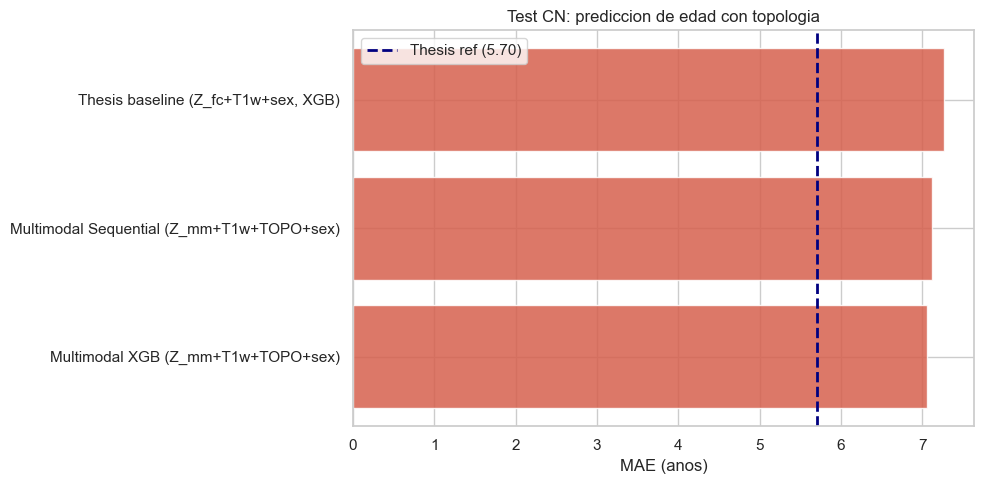

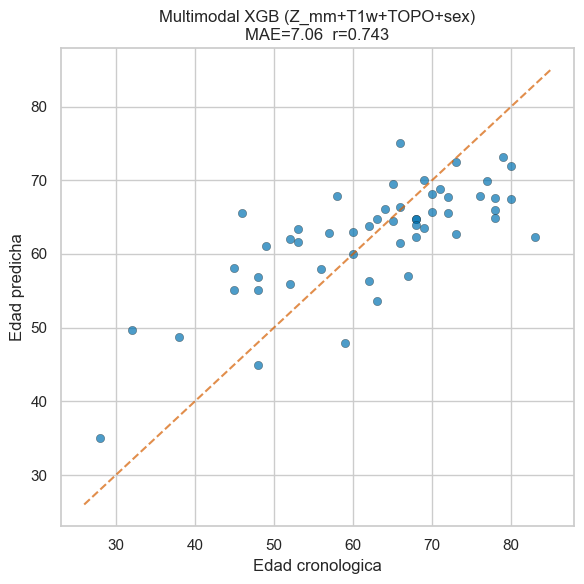

In [11]:
# Grafico: MAE test vs referencia Thesis
fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#4dac26" if s else "#d6604d" for s in test_df["supera_Thesis"]]
bars = ax.barh(test_df["Modelo"], test_df["MAE_test"], color=colors, alpha=0.85)
ax.axvline(THESIS_TEST_MAE, color="navy", ls="--", lw=2,
           label=f"Thesis ref ({THESIS_TEST_MAE:.2f})")
ax.set_xlabel("MAE (anos)")
ax.set_title("Test CN: prediccion de edad con topologia")
ax.legend()
plt.tight_layout()
plt.savefig("figs/06_test_MAE_comparison.png", dpi=150)
plt.show()

# Scatter pred vs real (mejor modelo)
best_name = test_df.iloc[0]["Modelo"]
pred_best = pred_store[best_name]
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_te, pred_best, alpha=0.7, edgecolors="k", linewidths=0.3)
lims = [min(y_te.min(), pred_best.min()) - 2, max(y_te.max(), pred_best.max()) + 2]
ax.plot(lims, lims, "r--", alpha=0.7)
m_best = regression_metrics(y_te, pred_best)
ax.set_xlabel("Edad cronologica")
ax.set_ylabel("Edad predicha")
ax.set_title(f"{best_name}\nMAE={m_best['MAE']:.2f}  r={m_best['Pearson']:.3f}")
plt.tight_layout()
plt.savefig("figs/06_test_scatter_best.png", dpi=150)
plt.show()

## 6. Guardar resultados

In [12]:
cv_df.drop("_mae", axis=1).to_csv("outputs/final_cv_results.csv", index=False)
test_df.to_csv("outputs/final_test_results.csv", index=False)

summary = {
    "thesis_reference_mae": THESIS_TEST_MAE,
    "best_model": best_name,
    "best_mae_test": float(test_df.iloc[0]["MAE_test"]),
    "beats_thesis": bool(test_df.iloc[0]["supera_Thesis"]),
    "n_cn_test": int(len(y_te)),
    "vae_multimodal_input_dim": int(X_vae_tv.shape[1]),
}
with open("outputs/final_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print("Guardado:")
print("  outputs/final_cv_results.csv")
print("  outputs/final_test_results.csv")
print("  outputs/final_summary.json")
print("  figs/06_test_MAE_comparison.png")
print("  figs/06_test_scatter_best.png")
print(f"\nMejor modelo: {best_name}")
print(f"MAE test: {summary['best_mae_test']:.2f}  |  Supera Thesis: {summary['beats_thesis']}")

Guardado:
  outputs/final_cv_results.csv
  outputs/final_test_results.csv
  outputs/final_summary.json
  figs/06_test_MAE_comparison.png
  figs/06_test_scatter_best.png

Mejor modelo: Multimodal XGB (Z_mm+T1w+TOPO+sex)
MAE test: 7.06  |  Supera Thesis: False
